# Домашнее задание: Multi-Branch MLP для Wine Quality

**Цель**: Реализовать multi-branch модель и добиться F1 score ≥ 40%

**Задачи**:
1. Реализовать три типа блоков: Bottleneck, Inverted Bottleneck, Regular
2. Создать Multi-Branch архитектуру
3. Использовать weighted loss для борьбы с дисбалансом классов
4. Подобрать оптимальные гиперпараметры (глубина, ширина, lr, оптимизатор)

In [34]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchmetrics import Accuracy, F1Score
import pytorch_lightning as pl
import sys
sys.path.append('../../lesson3/seminar')
from wine_quality_data import WineQualityDataModule
from lightning_module import BaseLightningModule
from utils import set_seed
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import Callback, EarlyStopping

sns.set_style('whitegrid')
set_seed(42)

## 1. Загрузка и анализ данных

Загрузим Wine Quality датасет и проанализируем распределение классов.

In [35]:
dm = WineQualityDataModule(batch_size=64)
dm.setup()

print(f'Train samples: {len(dm.train_dataset)}')
print(f'Val samples: {len(dm.val_dataset)}')
print(f'Input dim: {dm.input_dim}')
print(f'Num classes: {dm.n_classes}')

Train samples: 1279
Val samples: 320
Input dim: 11
Num classes: 6


### 1.1. Анализ дисбаланса классов

Проанализируйте распределение классов и вычислите веса для weighted loss.

,class,count,frequency,inverse_freq_weight,sqrt_weight,tuned_weight
0,0,8,0.63%,3.33,2.27,1.39
1,1,42,3.28%,0.63,0.99,1.39
2,2,545,42.61%,0.05,0.28,0.54
3,3,510,39.87%,0.05,0.28,0.54
4,4,159,12.43%,0.17,0.51,0.74
5,5,15,1.17%,1.77,1.66,1.39


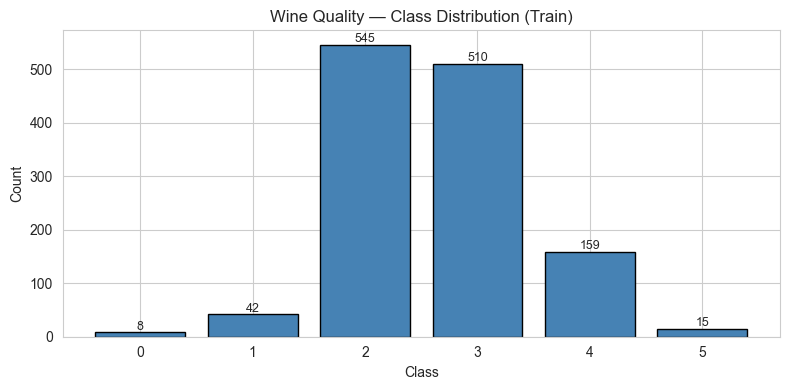

Classes:            [0 1 2 3 4 5]
Counts:             [  8  42 545 510 159  15]
Imbalance ratio:    68.1x
Inverse-freq loss:  [3.33 0.63 0.05 0.05 0.17 1.77]
Tuned loss weights: [1.39 1.39 0.54 0.54 0.74 1.39]


In [36]:
def make_class_weights(labels, power=1.0, clip=None):
    labels = np.asarray(labels)
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels).astype(np.float32)

    if power != 1.0:
        weights = np.power(weights, power)

    if clip is not None:
        weights = np.clip(weights, clip[0], clip[1])

    weights = weights / weights.mean()
    return classes, weights


train_labels = np.array([dm.train_dataset[i][1].item() for i in range(len(dm.train_dataset))])
unique, counts = np.unique(train_labels, return_counts=True)
frequencies = counts / counts.sum()

_, inverse_freq_weights = make_class_weights(train_labels, power=1.0)
_, sqrt_weights = make_class_weights(train_labels, power=0.5)
_, class_weights = make_class_weights(train_labels, power=0.55, clip=(0.85, 2.2))

class_distribution = pd.DataFrame({
    'class': unique,
    'count': counts,
    'frequency': frequencies,
    'inverse_freq_weight': inverse_freq_weights,
    'sqrt_weight': sqrt_weights,
    'tuned_weight': class_weights,
})

display(class_distribution.style.format({
    'frequency': '{:.2%}',
    'inverse_freq_weight': '{:.2f}',
    'sqrt_weight': '{:.2f}',
    'tuned_weight': '{:.2f}',
}))

plt.figure(figsize=(8, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Wine Quality — Class Distribution (Train)')
plt.xticks(unique)
for u, c in zip(unique, counts):
    plt.text(u, c + 5, str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f'Classes:            {unique}')
print(f'Counts:             {counts}')
print(f'Imbalance ratio:    {imbalance_ratio:.1f}x')
print(f'Inverse-freq loss:  {inverse_freq_weights.round(2)}')
print(f'Tuned loss weights: {class_weights.round(2)}')


## 2. Реализация блоков

Реализуйте три типа блоков:
- **Bottleneck**: dim → dim//4 → dim (сужение)
- **Inverted Bottleneck**: dim → dim*4 → dim (расширение)
- **Regular**: dim → hidden_dim → dim (обычный)

In [37]:
from abc import ABC, abstractmethod

class BaseMLPBlock(nn.Module, ABC):
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__()
        self.dim = dim
        self.activation = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'swish': nn.SiLU()}.get(activation, nn.GELU())
        self.norm = nn.LayerNorm(dim)
        self.dropout_layer = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    @abstractmethod
    def forward(self, x):
        pass

class BottleneckBlock(BaseMLPBlock):
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        self.bottleneck_dim = max(dim // 4, 1)
        self.fc1 = nn.Linear(self.dim, self.bottleneck_dim)
        self.fc2 = nn.Linear(self.bottleneck_dim, self.dim)

    def forward(self, x):
        identity = x
        out = self.norm(x)
        out = self.fc1(out)
        out = self.activation(out)
        out = self.dropout_layer(out)
        out = self.fc2(out)
        return out + identity

class InvertedBottleneckBlock(BaseMLPBlock):
    def __init__(self, dim, expansion_factor=4, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        self.expanded_dim = dim * expansion_factor
        self.fc1 = nn.Linear(self.dim, self.expanded_dim)
        self.fc2 = nn.Linear(self.expanded_dim, self.dim)

    def forward(self, x):
        identity = x
        out = self.norm(x)
        out = self.fc1(out)
        out = self.activation(out)
        out = self.dropout_layer(out)
        out = self.fc2(out)
        return out + identity

class RegularBlock(BaseMLPBlock):
    def __init__(self, dim, hidden_dim=None, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)
        self.hidden_dim = hidden_dim if hidden_dim else dim * 2
        self.fc1 = nn.Linear(self.dim, self.hidden_dim)
        self.fc2 = nn.Linear(self.hidden_dim, self.dim)

    def forward(self, x):
        identity = x
        out = self.norm(x)
        out = self.fc1(out)
        out = self.activation(out)
        out = self.dropout_layer(out)
        out = self.fc2(out)
        return out + identity


## 3. Multi-Branch модель

Реализуйте модель с тремя параллельными ветками.

**Архитектура**:
```
         Input
           |
      projection
           |
      ┌────┼────┐
      │    │    │
  Bottleneck  Inverted  Regular
   Branch      Branch    Branch
      │    │    │
      └────┼────┘
           |
      Concatenate/Sum
           |
      projection
           |
        Output
```

In [38]:
class MultiBranchMLP(nn.Module):
    """
    Multi-Branch MLP с тремя параллельными ветками.

    Args:
        input_dim: размерность входа
        hidden_dim: размерность скрытых слоев
        output_dim: размерность выхода (число классов)
        num_blocks: количество блоков в каждой ветке
        dropout: вероятность dropout
        combine_mode: способ объединения веток ('concat' или 'sum')
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_blocks=4,
        dropout=0.1,
        combine_mode='concat'
    ):
        super().__init__()
        self.output_dim = output_dim
        self.combine_mode = combine_mode

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )

        self.bottleneck_branch = nn.ModuleList(
            [BottleneckBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)]
        )
        self.inverted_branch = nn.ModuleList(
            [InvertedBottleneckBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)]
        )
        self.regular_branch = nn.ModuleList(
            [RegularBlock(hidden_dim, dropout=dropout) for _ in range(num_blocks)]
        )

        proj_input_dim = hidden_dim * 3 if combine_mode == 'concat' else hidden_dim
        self.output_head = nn.Sequential(
            nn.LayerNorm(proj_input_dim),
            nn.Linear(proj_input_dim, output_dim),
        )

    def forward(self, x):
        h = self.input_proj(x)

        h1 = h
        for block in self.bottleneck_branch:
            h1 = block(h1)

        h2 = h
        for block in self.inverted_branch:
            h2 = block(h2)

        h3 = h
        for block in self.regular_branch:
            h3 = block(h3)

        if self.combine_mode == 'concat':
            combined = torch.cat([h1, h2, h3], dim=-1)
        else:
            combined = h1 + h2 + h3

        return self.output_head(combined)


## 4. Код обучение

In [39]:
class MulticlassLightningModule(BaseLightningModule):
    def __init__(
        self,
        model,
        loss_fn,
        learning_rate=1e-3,
        optimizer_type='adamw',
        weight_decay=0.0,
        scheduler_patience=12,
    ):
        super().__init__(
            model=model,
            loss_fn=loss_fn,
            optimizer_type=optimizer_type,
            learning_rate=learning_rate,
            optimizer_kwargs={'weight_decay': weight_decay},
            task_type='multiclass',
        )
        self.weight_decay = weight_decay
        self.scheduler_patience = scheduler_patience
        self.val_f1_per_class = F1Score(task='multiclass', num_classes=model.output_dim, average='none')

    def on_validation_epoch_start(self):
        for metric in self.metrics.values():
            metric.reset()
        self.val_f1_per_class.reset()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self.forward(x)
        loss = self.loss_fn(logits, y)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self._update_multiclass_metrics(y, logits)
        self.val_f1_per_class.update(logits, y)
        return loss

    def on_validation_epoch_end(self):
        metrics_str = []
        for metric_name in self.metrics_to_log:
            if metric_name in self.metrics:
                metric_value = self.metrics[metric_name].compute()
                metric_item = metric_value.item() if metric_value.numel() == 1 else float(metric_value)
                self.log(f'val_{metric_name}', metric_item, on_step=False, on_epoch=True, sync_dist=False)
                metrics_str.append(f"{metric_name}={metric_item:.4f}")

        per_class_f1 = self.val_f1_per_class.compute()
        for class_idx, class_f1 in enumerate(per_class_f1):
            self.log(f'val_f1_class_{class_idx}', class_f1.item(), on_step=False, on_epoch=True, sync_dist=False)

        print(f"Epoch {self.current_epoch}: " + ', '.join(metrics_str))

    def configure_optimizers(self):
        optimizer_kwargs = {'lr': self.learning_rate, **self.optimizer_kwargs}
        if self.optimizer_type == 'adamw':
            optimizer = torch.optim.AdamW(self.parameters(), **optimizer_kwargs)
        elif self.optimizer_type == 'adam':
            optimizer = torch.optim.Adam(self.parameters(), **optimizer_kwargs)
        elif self.optimizer_type == 'sgd':
            optimizer = torch.optim.SGD(self.parameters(), momentum=0.9, **optimizer_kwargs)
        else:
            raise ValueError(f'Unknown optimizer: {self.optimizer_type}')

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.5,
            patience=self.scheduler_patience,
            min_lr=1e-5,
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_f1_macro',
                'interval': 'epoch',
                'frequency': 1,
            }
        }


class BestMetricTracker(Callback):
    def __init__(self, monitor='val_f1_macro', mode='max'):
        super().__init__()
        self.monitor = monitor
        self.mode = mode
        self.best_score = -float('inf') if mode == 'max' else float('inf')
        self.best_epoch = -1
        self.best_model_state_dict = None
        self.best_metrics = {}

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        score = metrics.get(self.monitor)
        if score is None:
            return

        score = score.item() if torch.is_tensor(score) else float(score)
        is_better = score > self.best_score if self.mode == 'max' else score < self.best_score
        if is_better:
            self.best_score = score
            self.best_epoch = trainer.current_epoch
            self.best_model_state_dict = {
                key: value.detach().cpu().clone()
                for key, value in pl_module.model.state_dict().items()
            }
            self.best_metrics = {
                name: (value.item() if torch.is_tensor(value) else float(value))
                for name, value in metrics.items()
                if name.startswith('val_')
            }


def build_weighted_sampler(dataset, power=0.5):
    labels = np.array([dataset[i][1].item() for i in range(len(dataset))])
    classes = np.unique(labels)
    class_weights = compute_class_weight('balanced', classes=classes, y=labels).astype(np.float32)
    class_weights = np.power(class_weights, power)
    sample_weights = class_weights[labels]
    return WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )


@torch.no_grad()
def evaluate_multiclass_model(model, dataloader, class_names=None):
    model.eval()
    y_true = []
    y_pred = []

    for x, y in dataloader:
        logits = model(x)
        preds = logits.argmax(dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = np.unique(y_true)

    if class_names is None:
        class_names = [str(label) for label in labels]

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return report_df, cm


def train_model(
    model,
    dm,
    class_weights=None,
    max_epochs=50,
    lr=1e-3,
    optimizer_type='adam',
    weight_decay=0.0,
    label_smoothing=0.0,
    early_stop_patience=40,
    use_weighted_sampler=True,
    sampler_power=0.5,
    scheduler_patience=12,
):
    """
    Обучает модель с weighted loss и возвращает метрики лучшей эпохи.

    Args:
        model: модель для обучения
        dm: DataModule
        class_weights: веса классов для weighted loss (numpy array или None)
        max_epochs: количество эпох
        lr: learning rate
        optimizer_type: тип оптимизатора ('adam', 'adamw', 'sgd')
        weight_decay: L2-регуляризация для оптимизатора
        label_smoothing: сглаживание меток для стабилизации обучения
        early_stop_patience: patience для остановки по val_f1_macro
        use_weighted_sampler: oversampling редких классов в train-loader
        sampler_power: сила oversampling-а редких классов
        scheduler_patience: patience для ReduceLROnPlateau

    Returns:
        dict с метриками
    """
    weight_tensor = None
    if class_weights is not None:
        weight_tensor = torch.tensor(class_weights, dtype=torch.float32)

    loss_fn = nn.CrossEntropyLoss(weight=weight_tensor, label_smoothing=label_smoothing)

    lightning_model = MulticlassLightningModule(
        model=model,
        loss_fn=loss_fn,
        learning_rate=lr,
        optimizer_type=optimizer_type,
        weight_decay=weight_decay,
        scheduler_patience=scheduler_patience,
    )

    train_loader = dm.train_dataloader()
    if use_weighted_sampler:
        train_loader = DataLoader(
            dm.train_dataset,
            batch_size=dm.batch_size,
            sampler=build_weighted_sampler(dm.train_dataset, power=sampler_power),
            num_workers=0,
        )
    val_loader = dm.val_dataloader()

    best_model_callback = BestMetricTracker(monitor='val_f1_macro', mode='max')
    early_stopping = EarlyStopping(
        monitor='val_f1_macro',
        mode='max',
        patience=early_stop_patience,
        min_delta=1e-4,
    )

    trainer = Trainer(
        max_epochs=max_epochs,
        callbacks=[best_model_callback, early_stopping],
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        enable_model_summary=False,
        deterministic=True,
        gradient_clip_val=0.5,
        num_sanity_val_steps=0,
        log_every_n_steps=1,
    )
    trainer.fit(lightning_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

    if best_model_callback.best_model_state_dict is not None:
        lightning_model.model.load_state_dict(best_model_callback.best_model_state_dict)

    metrics = best_model_callback.best_metrics
    return {
        'val_acc': float(metrics.get('val_accuracy', 0.0)),
        'val_f1': float(metrics.get('val_f1_macro', 0.0)),
        'best_epoch': best_model_callback.best_epoch,
    }


## 5. Итоговая модель

Обучите модель с лучшими гиперпараметрами.

In [40]:
set_seed(42)

final_model = MultiBranchMLP(
    input_dim=dm.input_dim,
    hidden_dim=96,
    output_dim=dm.n_classes,
    num_blocks=2,
    dropout=0.15,
    combine_mode='concat'
)

print(f'Параметров модели: {sum(p.numel() for p in final_model.parameters()):,}')

final_results = train_model(
    final_model,
    dm,
    class_weights=sqrt_weights,
    max_epochs=350,
    lr=8e-4,
    optimizer_type='adamw',
    weight_decay=5e-3,
    label_smoothing=0.0,
    early_stop_patience=60,
    use_weighted_sampler=True,
    sampler_power=0.5,
    scheduler_patience=10,
)

print(f"\n=== Итоговые результаты ===")
print(f"Best epoch:        {final_results['best_epoch']}")
print(f"F1 score (macro): {final_results['val_f1']:.4f}")
print(f"Accuracy:         {final_results['val_acc']:.4f}")


Epoch 104/349 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 0:00:00 • 0:00:00 48.29it/s train_loss_step: 0.022 val_loss:  
                                                                                 4.145 train_loss_epoch: 0.011     


=== Итоговые результаты ===
Best epoch:        45
F1 score (macro): 0.4002
Accuracy:         0.6406


,precision,recall,f1-score,support
0,0.000,0.000,0.000,2.0
1,0.133,0.182,0.154,11.0
2,0.653,0.691,0.671,136.0
3,0.643,0.562,0.600,128.0
4,0.561,0.575,0.568,40.0
5,0.200,0.333,0.250,3.0


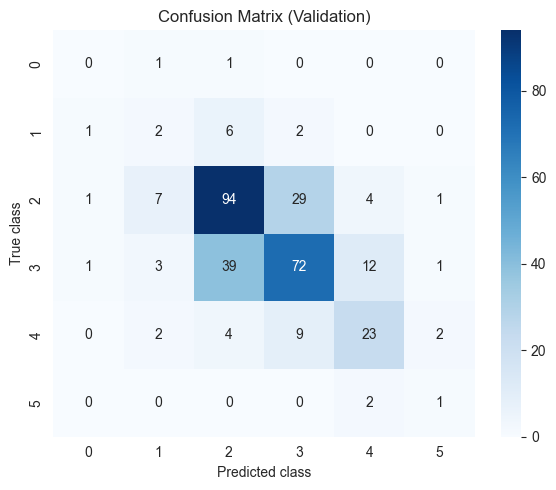

In [41]:
report_df, cm = evaluate_multiclass_model(
    final_model,
    dm.val_dataloader(),
    class_names=[str(cls) for cls in unique],
)

display(report_df.loc[[str(cls) for cls in unique], ['precision', 'recall', 'f1-score', 'support']].round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=unique,
    yticklabels=unique,
)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion Matrix (Validation)')
plt.tight_layout()
plt.show()


In [ ]:
set_seed(42)

search_results = []

def run_search_experiment(hidden_dim, num_blocks, lr, optimizer_type, combine_mode='concat', dropout=0.15, weights=sqrt_weights, sampler_power=0.5):
    set_seed(42)
    model = MultiBranchMLP(
        input_dim=dm.input_dim,
        hidden_dim=hidden_dim,
        output_dim=dm.n_classes,
        num_blocks=num_blocks,
        dropout=dropout,
        combine_mode=combine_mode,
    )
    result = train_model(
        model,
        dm,
        class_weights=weights,
        max_epochs=180,
        lr=lr,
        optimizer_type=optimizer_type,
        weight_decay=5e-3 if optimizer_type != 'sgd' else 1e-3,
        label_smoothing=0.0,
        early_stop_patience=35,
        use_weighted_sampler=True,
        sampler_power=sampler_power,
        scheduler_patience=8,
    )
    return {
        'hidden_dim': hidden_dim,
        'num_blocks': num_blocks,
        'lr': lr,
        'optimizer': optimizer_type,
        'f1_macro': result['val_f1'],
        'accuracy': result['val_acc'],
        'best_epoch': result['best_epoch'],
    }

for num_blocks in [2, 4, 6, 8]:
    search_results.append(run_search_experiment(hidden_dim=96, num_blocks=num_blocks, lr=1e-3, optimizer_type='adamw'))

for hidden_dim in [64, 128, 256]:
    search_results.append(run_search_experiment(hidden_dim=hidden_dim, num_blocks=2, lr=1e-3, optimizer_type='adamw'))

for lr in [1e-2, 1e-3, 1e-4]:
    search_results.append(run_search_experiment(hidden_dim=96, num_blocks=2, lr=lr, optimizer_type='adamw'))

for optimizer_type in ['adam', 'adamw', 'sgd']:
    search_results.append(run_search_experiment(hidden_dim=96, num_blocks=2, lr=1e-3, optimizer_type=optimizer_type))

search_df = pd.DataFrame(search_results).drop_duplicates(subset=['hidden_dim', 'num_blocks', 'lr', 'optimizer'])
display(search_df.sort_values('f1_macro', ascending=False).reset_index(drop=True))

best_row = search_df.sort_values('f1_macro', ascending=False).iloc[0]
print(f"\nЛучшая F1:     {best_row['f1_macro']:.4f}")
print(f"Accuracy:      {best_row['accuracy']:.4f}")
print(f"Best epoch:    {int(best_row['best_epoch'])}")
print(f"Configuration: hidden_dim={int(best_row['hidden_dim'])}, num_blocks={int(best_row['num_blocks'])}, lr={best_row['lr']}, optimizer={best_row['optimizer']}")


Epoch 49/179 ━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/20 0:00:00 • 0:00:01 47.89it/s train_loss_step: 0.039 val_loss:  
                                                                                 4.012 train_loss_epoch: 0.085     